<a href="https://colab.research.google.com/github/m1deey/Churn_customer_prediction/blob/main/Vasules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
import pandas as pd
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [52]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7.043000e+03,7.043000e+03
mean,0.162147,32.371149,-6.406285e-17,-1.488074e-17
std,0.368612,24.559481,1.000071e+00,1.000071e+00
min,0.000000,0.000000,-1.545860e+00,-9.991203e-01
25%,0.000000,9.000000,-9.725399e-01,-8.298459e-01
50%,0.000000,29.000000,1.857327e-01,-3.904632e-01
75%,0.000000,55.000000,8.338335e-01,6.642871e-01
max,1.000000,72.000000,1.794352e+00,2.826743e+00


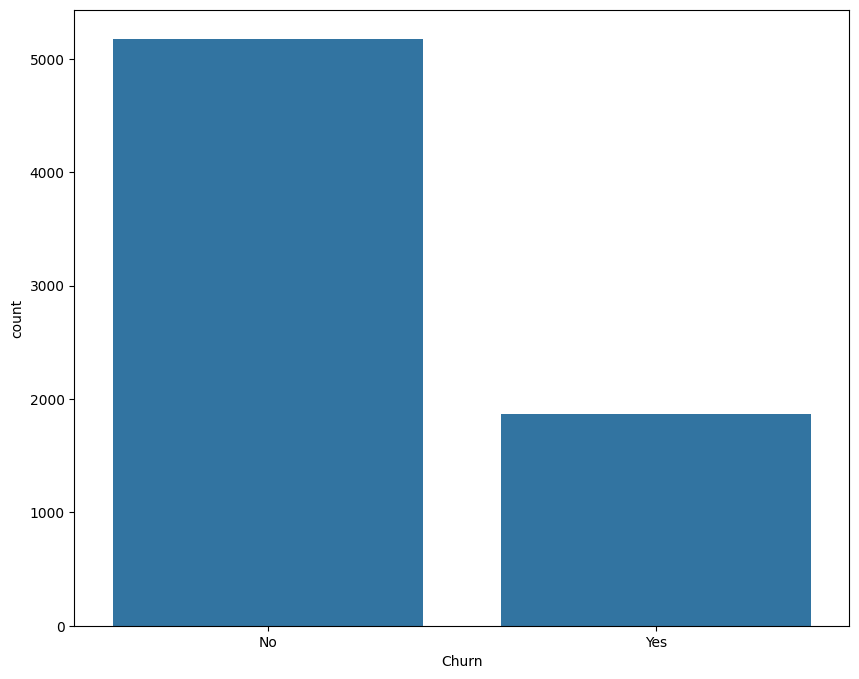

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.countplot(data=df,x="Churn")
plt.show()

The output is not balanced we have the customer will churn more then he will not churn

In [20]:
print(df.select_dtypes("number").columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


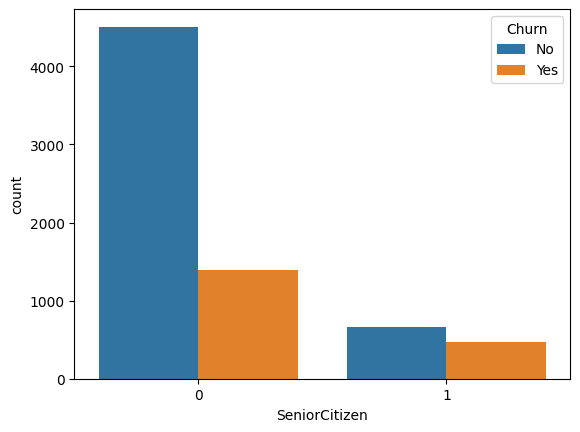

In [25]:
sns.countplot(data=df,x="SeniorCitizen",hue="Churn")
plt.show()

Nothing interesting but the difference in non seniors is bigger then the seniors

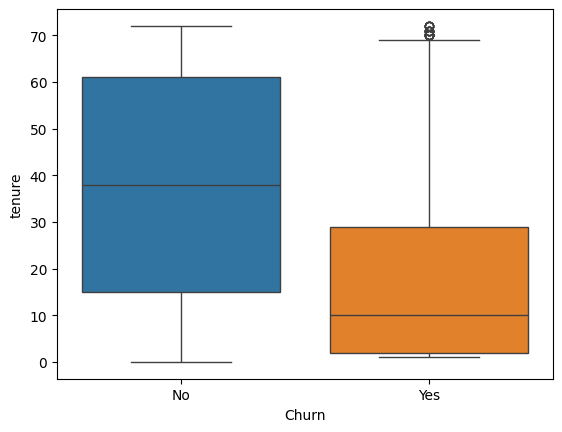

In [29]:
sns.boxplot(data=df,x="Churn",y="tenure",hue="Churn")
plt.show()

the customers with hight tenure are the most ones who will not churn

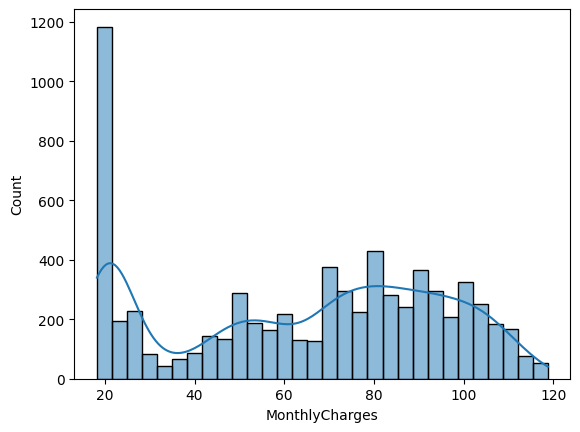

In [31]:
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.show()

Most of the costumers pay 20$ monthly

We have to scale the values to have a readable graph

but the problem there is obejcts in total charges we have to replace them

In [107]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)

/tmp/ipykernel_1929/1421962581.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(),inplace=True)


In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["MonthlyCharges","tenure","TotalCharges"]] = scaler.fit_transform(
    df[["MonthlyCharges","tenure","TotalCharges"]]
)

Let's see the graphs now

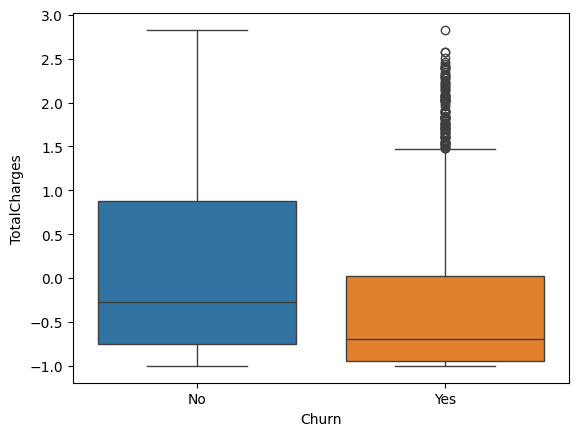

In [49]:
sns.boxplot(data=df,y="TotalCharges",x="Churn",hue="Churn")
plt.show()

Customers who have high total charges mostly will not churn

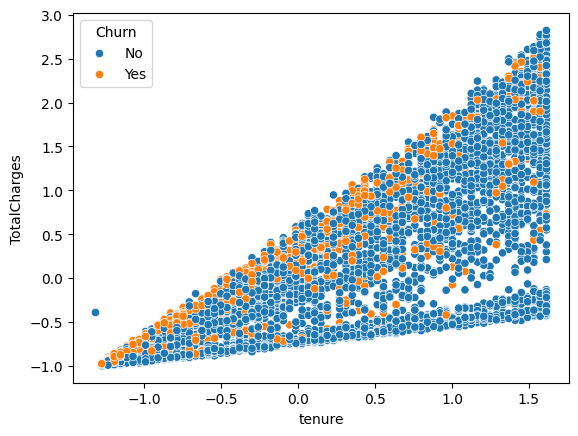

In [98]:

sns.scatterplot(data=df,y="TotalCharges",x="tenure",hue="Churn")
plt.show()

TotalCharges and tenure have strong relation , the more tenure customer have tk more total charges are

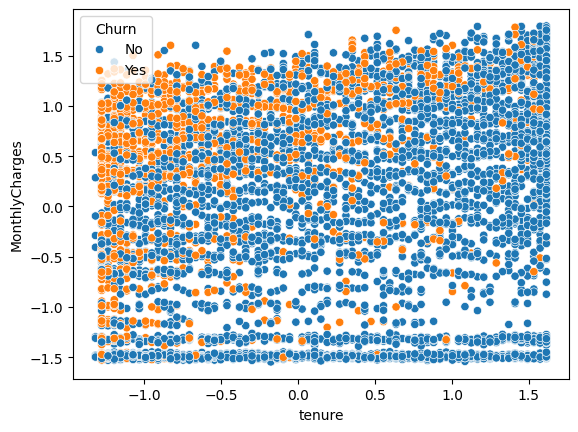

In [99]:
sns.scatterplot(data=df,y="MonthlyCharges",x="tenure",hue="Churn")
plt.show()

Customers with low tenure and relatively high monthly charges appear more likely to churn In contrast and customers with longer tenure are more likely to remain with the company even when their monthly charges are high

In [58]:
print(df.select_dtypes("object").columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


I will just do the important graph after i check them all

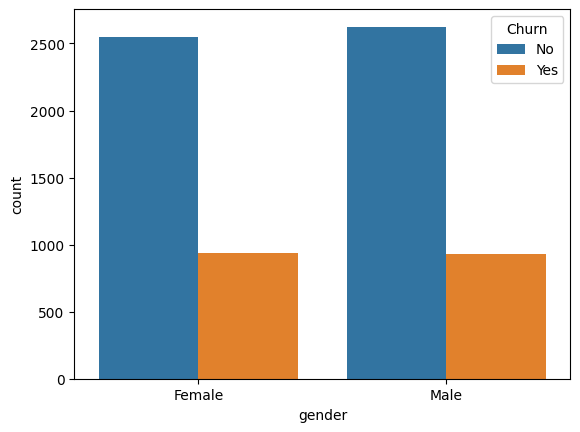

In [64]:
sns.countplot(data=df, x="gender", hue="Churn")
plt.show()

Gender has almost no effect on customer churn, with both male and female customers showing nearly identical churn rates (~26%). This feature may have limited predictive value.
Considering dropping the column gender

We can just replace no phone service with no cz its the same

In [109]:
df["MultipleLines"] = df["MultipleLines"].replace("No phone service", "No")

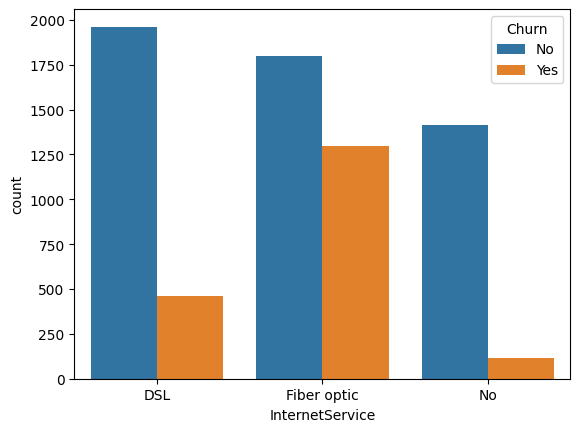

In [110]:
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.show()

Fiber optic customers have the highest churn rate, while customers with no internet service have the lowest.

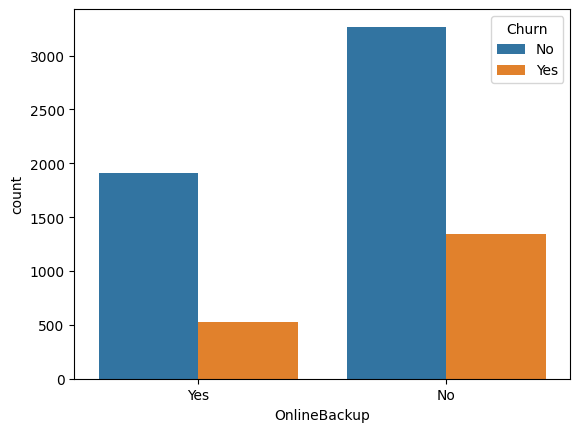

In [113]:
df["OnlineBackup"] = df["OnlineBackup"].replace("No internet service", "No")
sns.countplot(data=df, x="OnlineBackup", hue="Churn")
plt.show()

Customers without Online Security, Tech Support, Device Protection, or Online Backup are more likely to churn than those who subscribe to these additional services.

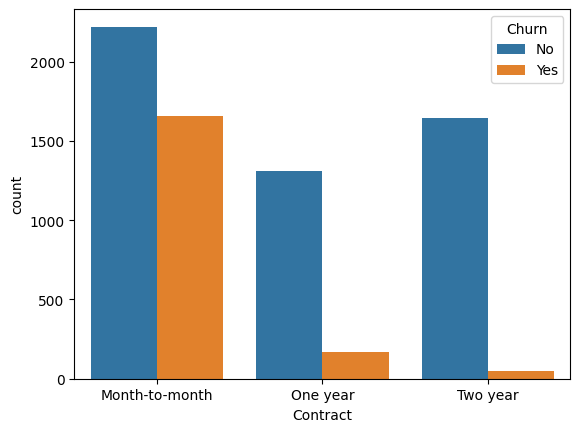

In [117]:
sns.countplot(data=df, x="Contract", hue="Churn")
plt.show()

Customers with month-to-month contracts are much more likely to churn than customers with one- or two-year contract making Contract one of the strongest predictors

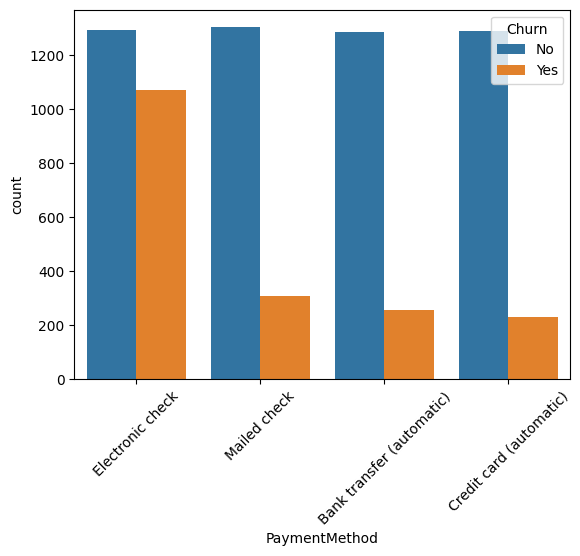

In [87]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=45)
plt.show()

Electronic check is associated with the highest churn among payment methods, while automatic payment methods show lower churn.

In [118]:
df.groupby("gender")["Churn"].value_counts(normalize=True)

gender  Churn
Female  No       0.730791
        Yes      0.269209
Male    No       0.738397
        Yes      0.261603
Name: proportion, dtype: float64

The gender have no corr with the churn as we seen lately in the graoh so dropping it will be better with dropping the id to

In [119]:
df=df.drop(columns=["customerID","gender"])

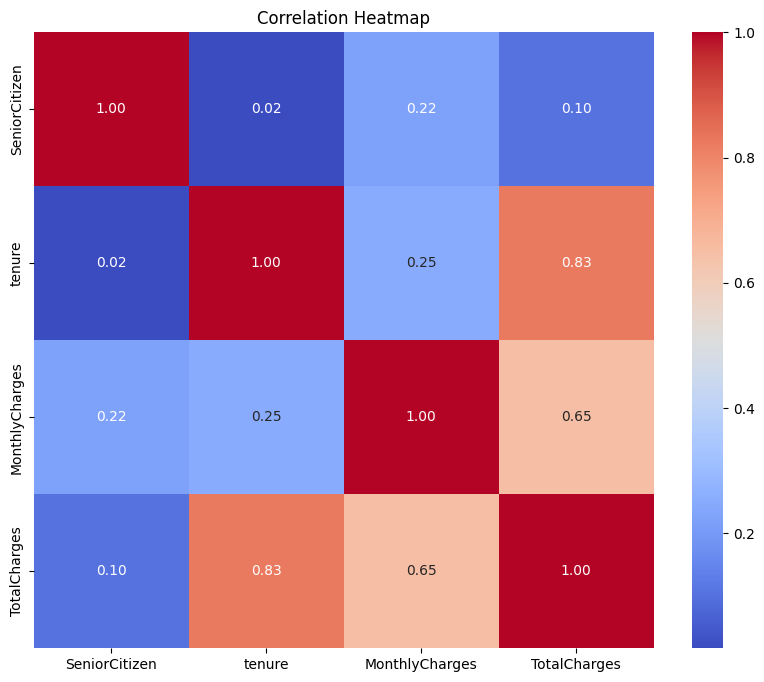

In [120]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

No fueture is highly correlated with another one

#Overall
, Contract type, Tenure, Internet Service, Monthly Charges, and additional service subscriptions appear to be the most informative features for predicting customer churn.